In [ ]:
%pip install -qq -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import params

params.configure_renku_cuda()
device = params.select_device()
print(f'Using device: {device}')

/home/renku/work/convNPClimate/params.py:86: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert (not (not self.SEASONAL_FEATURES and self.SEASONAL_FEATURES_IN_MLP),


Using device: cuda


In [ ]:
# Training configuration - modify these parameters as needed
PW_FIRST_DATE        = '2017-01-01'
PW_LAST_DATE         = '2024-12-31'
PW_VALIDITY_THRESHOLD = 0.99

PARAMS = params.Params(
    VARIABLE='tmax',
    MODEL_TYPE='smacnp',
    CONTEXT_TYPE='peakweather',
    PW_TRAIN_FRAC=0.6,
    PW_VAL_FRAC=0.2,
    STATION_SPLIT_SEED=42,
    N_EPOCHS=30,
    N_FOLDS=5,
    TRIAL_NAME='test-2017-30e-5f-smacnp-pw-mean',
    RUN_TYPE='cloud' if params.is_renku() else 'local',
    BATCH_SIZE=8 if params.is_renku() else 16,
    DEVICE=device,
    SEASONAL_FEATURES=True,
    # SMACNP architecture
    R_DIM=128,
    W_DIM=128,
    V_DIM=128,
    N_HEADS=4,
    SMACNP_HIDDEN=128,
    USE_PE=True,
    PE_DIM=32,
)



print(f"Configuration: {PARAMS}")

Configuration: Params(VARIABLE='tmax', DATA_YEAR_START=2023, SEASONAL_FEATURES=True, SEASONAL_FEATURES_IN_MLP=True, USE_ELEVATION=True, USE_MTPI=True, N_CHANNELS=128, N_BLOCKS=6, KERNEL_SIZE=5, LENGTH_SCALE=0.1, IN_CHANNELS=0, N_EPOCHS=30, BATCH_SIZE=8, LR=0.0005, PATIENCE=20, N_FOLDS=5, SEED=42, TRIAL_NAME='test-2017-30e-5f-smacnp-pw-2', RUN_TYPE='cloud', DEVICE=device(type='cuda'), ERA5_MAX_TEMP_GLOB=None, ERA5_GEOPOTENTIAL_GLOB=None, METEO_SWISS_MAX_TEMP_GLOB=None, HI_RES_TOPOGRAPHY_ZARR_PATH=None, MODEL_TYPE='smacnp', R_DIM=128, W_DIM=128, V_DIM=128, N_HEADS=4, SMACNP_HIDDEN=128, USE_PE=True, PE_DIM=32, PW_TRAIN_FRAC=0.6, PW_VAL_FRAC=0.2, STATION_SPLIT_SEED=42, CONTEXT_TYPE='peakweather')


In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.optim as optim

import datasets as ds
import model_factory
import cloud_sync
import visualization as vis
from convCNP.training.training_elev import train_smacnp

In [ ]:
# Define all paths as local - these are where data will be read from
BASE_DIR = Path('.')
OUTPUT_DIR = BASE_DIR / 'trained_models' / PARAMS.TRIAL_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BASE_DATASET_DIR = BASE_DIR / 'datasets'
REMOTE_OUTPUT_DIR = Path().cwd() / '..' / 'trained-models-mount' / PARAMS.TRIAL_NAME
REMOTE_DATASET_DIR = Path().cwd() / '..' / 'datasets-mount'

# Note: loading datasets on Renkulab directly from Polybox was no working well.
# Things do work if we first sync the files over to local storage and then load them
# locally.
cloud_sync.sync_from_cloud_if_needed(REMOTE_DATASET_DIR, BASE_DATASET_DIR, PARAMS.RUN_TYPE)

# Save data paths in params for reproducibility (used by predictions notebook)
PARAMS = PARAMS.with_data_paths(ds.build_data_paths(BASE_DATASET_DIR))

Cloud run detected. Syncing data from /home/renku/work/convNPClimate/../datasets-mount to datasets...
Synchronizing directory datasets with /home/renku/work/convNPClimate/../datasets-mount
Source directory: /home/renku/work/convNPClimate/../datasets-mount:
Copying file tp-2019.nc from /home/renku/work/convNPClimate/../datasets-mount/ERA5_Land/precipitation to datasets/ERA5_Land/precipitation
Copying file TabsD_ch01r.swiss.lv95_196301010000_196312310000.nc from /home/renku/work/convNPClimate/../datasets-mount/MeteoSwiss/TabsD_v2.0_swiss.lv95 to datasets/MeteoSwiss/TabsD_v2.0_swiss.lv95
Copying file t2m_min-2009.nc from /home/renku/work/convNPClimate/../datasets-mount/ERA5_Land/min_temperature to datasets/ERA5_Land/min_temperature
Copying file t2m_max-1993.nc from /home/renku/work/convNPClimate/../datasets-mount/ERA5_Land/max_temperature to datasets/ERA5_Land/max_temperature
Copying file 0.0 from /home/renku/work/convNPClimate/../datasets-mount/topo_subset.zarr/SN_DERIVATIVE_500M_SIGRATI

In [ ]:
# Load PeakWeather stations (all valid stations, before split)
daily_tmean, stations_meta, valid_stations = ds.load_peakweather_stations(
    first_date=PW_FIRST_DATE,
    last_date=PW_LAST_DATE,
    validity_threshold=PW_VALIDITY_THRESHOLD,
    station_type=None,
    aggregation_method='mean',
)
pw_dates_pd = pd.DatetimeIndex(daily_tmean.index.date.astype(str))

# Seasonal features from PW time axis
pw_times_np = np.array(pw_dates_pd, dtype='datetime64[D]')
if PARAMS.SEASONAL_FEATURES:
    seasonal_features = ds.compute_seasonal_features(pw_times_np, device=device)
    print(f"Seasonal features shape: {seasonal_features.shape}")
else:
    seasonal_features = None


Loading PeakWeather stations (None) from 2017-01-01 to 2024-12-31 ...
  184 / 302 stations pass validity threshold (90%)
  Daily tmax shape: (2921, 184)  (2017-01-01 → 2024-12-30)
  Altitude range: [203, 3571] m
Computed seasonal features: torch.Size([2921, 2]), dtype: torch.float32
Seasonal features shape: torch.Size([2921, 2])


In [ ]:
hi_res_elevation, hi_res_tpi = ds.load_high_res_topography(PARAMS.HI_RES_TOPOGRAPHY_ZARR_PATH)

Loading high-resolution topography from Zarr: datasets/topo_subset.zarr
Topography dataset dimensions: FrozenMappingWarningOnValuesAccess({'y': 12800, 'x': 14200})
DEM shape: (12800, 14200), dtype: int16
TPI (TPI_500M) shape: (12800, 14200), dtype: float32


In [ ]:
# Split stations 60 / 20 / 20
train_stations, val_stations, test_stations = ds.split_peakweather_stations(
    valid_stations,
    train_frac=PARAMS.PW_TRAIN_FRAC,
    val_frac=PARAMS.PW_VAL_FRAC,
    seed=PARAMS.STATION_SPLIT_SEED,
)

# Compute normalization stats from train stations only
pw_metadata = ds.compute_pw_metadata(daily_tmean, train_stations)
print(f"PW metadata: mean={pw_metadata.data_mean:.2f} K, std={pw_metadata.data_std:.2f} K")


Station split: 110 train / 36 val / 38 test
PW train stats: mean=285.13 K, std=9.28 K
PW metadata: mean=285.13 K, std=9.28 K


In [ ]:
x_context, y_context = ds.build_pw_station_tensors(
    daily_tmax=daily_tmean,
    station_ids=train_stations,
    stations_meta=stations_meta,
    hi_res_tpi=hi_res_tpi,
    metadata=pw_metadata,
    seasonal_features=seasonal_features,
    dates_pd=pw_dates_pd,
    device=device,
)
# y_context must be (T, N, 1) for SMACNP
y_context = y_context.unsqueeze(-1)
# Fill NaN context observations with 0 (normalized mean) so attention is not disrupted
y_context = torch.nan_to_num(y_context, nan=0.0)

print(f"x_context: {x_context.shape}  # (T, N_train, 6)")
print(f"y_context: {y_context.shape}  # (T, N_train, 1)")


x_context: torch.Size([2921, 110, 6])  # (T, N_train, 6)
y_context: torch.Size([2921, 110, 1])  # (T, N_train, 1)


In [ ]:
params.set_seed(PARAMS.SEED)

In [ ]:
stats_file = os.path.join(OUTPUT_DIR, 'stats.csv')

In [ ]:
# Save config and PW metadata for prediction notebooks
PARAMS.save_json(OUTPUT_DIR / 'params.json')
ds.save_metadata_json(pw_metadata, OUTPUT_DIR / 'metadata.json')

# Build val targets once — fixed station set, no subsampling needed
x_target, y_target = ds.build_pw_station_tensors(
    daily_tmax=daily_tmean,
    station_ids=val_stations,
    stations_meta=stations_meta,
    hi_res_tpi=hi_res_tpi,
    metadata=pw_metadata,
    seasonal_features=seasonal_features,
    dates_pd=pw_dates_pd,
    device=device,
)
print(f"x_target: {x_target.shape}  # (T, N_val, 6)")
print(f"y_target: {y_target.shape}  # (T, N_val)")

STATS_HEADER = 'Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL\n'

for fold in range(PARAMS.N_FOLDS):
    print(f'\nStarting fold {fold + 1}/{PARAMS.N_FOLDS}...\n')

    fold_stats_file = os.path.join(OUTPUT_DIR, f'stats_fold{fold}.csv')
    if not os.path.exists(fold_stats_file):
        with open(fold_stats_file, 'w') as f:
            f.write(STATS_HEADER)

    params.set_seed(PARAMS.SEED + fold)
    model, loss_fn, get_value_fn = model_factory.build_smacnp(PARAMS, x_context.shape[-1])
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=PARAMS.LR)

    train_smacnp(
        model=model,
        opt=optimizer,
        ll=loss_fn,
        x_context=x_context,
        y_context=y_context,
        x_target=x_target,
        y_target=y_target,
        output_dir=OUTPUT_DIR,
        get_value=get_value_fn,
        fold=fold,
        n_folds=PARAMS.N_FOLDS,
        n_epochs=PARAMS.N_EPOCHS,
        batch_size=PARAMS.BATCH_SIZE,
        patience=PARAMS.PATIENCE,
        stats_file=fold_stats_file,
        device=device,
    )

    cloud_sync.sync_to_cloud_if_needed(OUTPUT_DIR, REMOTE_OUTPUT_DIR, PARAMS.RUN_TYPE)

# Merge per-fold stats into a single stats.csv
fold_csvs = [os.path.join(OUTPUT_DIR, f'stats_fold{f}.csv') for f in range(PARAMS.N_FOLDS)]
pd.concat([pd.read_csv(p) for p in fold_csvs if os.path.exists(p)]).to_csv(
    os.path.join(OUTPUT_DIR, 'stats.csv'), index=False
)
print(f'\nTraining finished. Models saved in {OUTPUT_DIR}.')


x_target: torch.Size([2921, 36, 6])  # (T, N_val, 6)
y_target: torch.Size([2921, 36])  # (T, N_val)

Starting fold 1/5...

Built SMACNP with 308,995 trainable parameters
Fold 1/5 | Epoch 0 | train NLL 0.079 | test NLL 0.094 | med MAE 0.124 | elapsed 6s | est. remaining 174s
Fold 1/5 | Epoch 1 | train NLL 0.070 | test NLL 0.073 | med MAE 0.093 | elapsed 9s | est. remaining 132s
Fold 1/5 | Epoch 2 | train NLL 0.062 | test NLL 0.070 | med MAE 0.091 | elapsed 13s | est. remaining 115s
Fold 1/5 | Epoch 3 | train NLL 0.070 | test NLL 0.079 | med MAE 0.103 | elapsed 16s | est. remaining 104s
Fold 1/5 | Epoch 4 | train NLL 0.057 | test NLL 0.066 | med MAE 0.085 | elapsed 19s | est. remaining 97s
Fold 1/5 | Epoch 5 | train NLL 0.059 | test NLL 0.074 | med MAE 0.097 | elapsed 23s | est. remaining 91s
Fold 1/5 | Epoch 6 | train NLL 0.054 | test NLL 0.064 | med MAE 0.083 | elapsed 26s | est. remaining 85s
Fold 1/5 | Epoch 7 | train NLL 0.057 | test NLL 0.074 | med MAE 0.090 | elapsed 29s | est. re

In [ ]:
OUTPUT_DIR
fold_csvs = [os.path.join(OUTPUT_DIR, f'stats_fold{f}.csv') for f in range(PARAMS.N_FOLDS)]
pd.concat([pd.read_csv(p) for p in fold_csvs if os.path.exists(p)]).to_csv(stats_file, index=False)

In [ ]:
print(stats_file)
stats = pd.read_csv(stats_file)
stats

trained_models/test-2017-30e-5f-smacnp-pw-2/stats.csv


,Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL
0,0,0.123712,0.989726,0.990403,0,0.079261,0.094304
1,0,0.092955,0.991684,0.992554,1,0.070007,0.073041
2,0,0.090562,0.993081,0.993335,2,0.061895,0.069818
3,0,0.102667,0.993004,0.993655,3,0.069791,0.079228
4,0,0.084869,0.993735,0.994230,4,0.057097,0.065849
...,...,...,...,...,...,...,...
145,4,0.076960,0.993399,0.993516,25,0.058129,0.057870
146,4,0.078894,0.993238,0.993558,26,0.052937,0.059969
147,4,0.076766,0.993401,0.993552,27,0.052694,0.056883
148,4,0.078691,0.993248,0.993491,28,0.054574,0.059802


  Saved plot: trained_models/test-2017-30e-5f-smacnp-pw-2/trainingstats_fold0


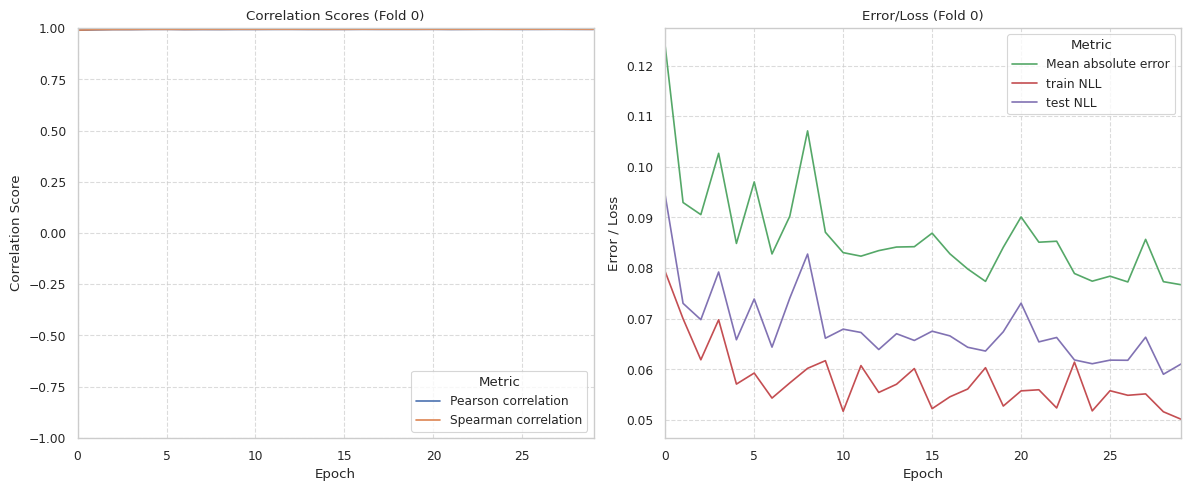

  Saved plot: trained_models/test-2017-30e-5f-smacnp-pw-2/trainingstats_fold1


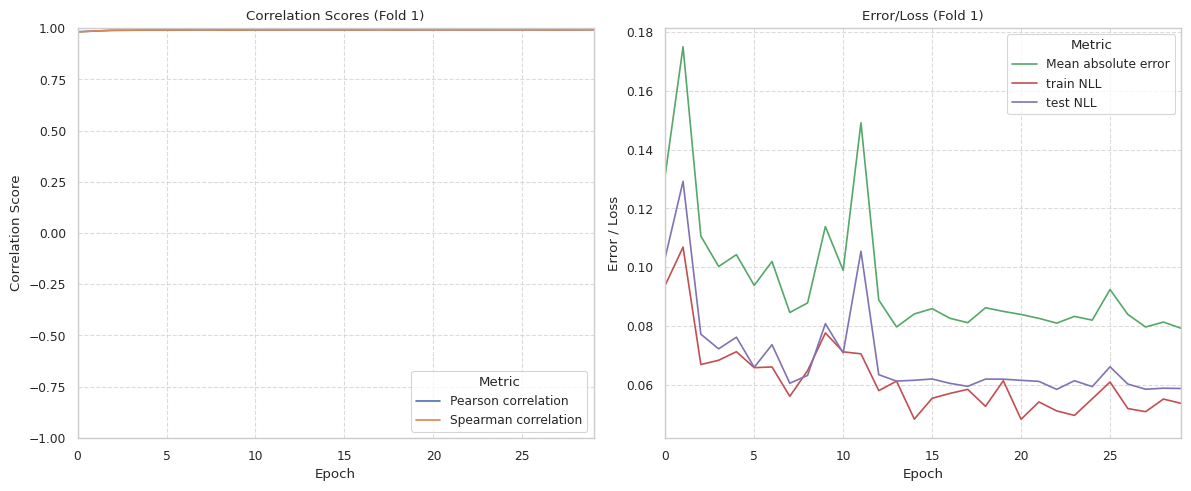

  Saved plot: trained_models/test-2017-30e-5f-smacnp-pw-2/trainingstats_fold2


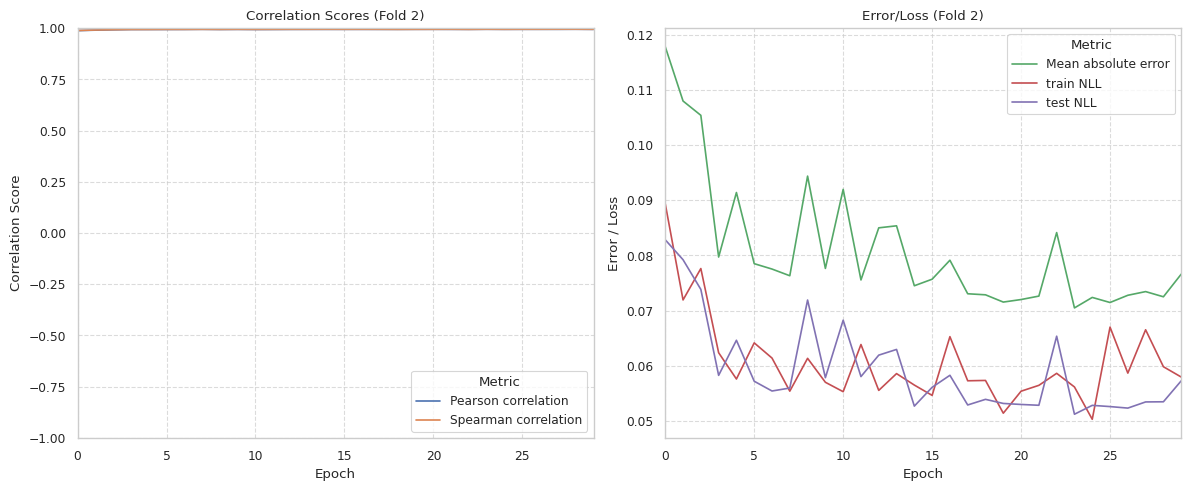

  Saved plot: trained_models/test-2017-30e-5f-smacnp-pw-2/trainingstats_fold3


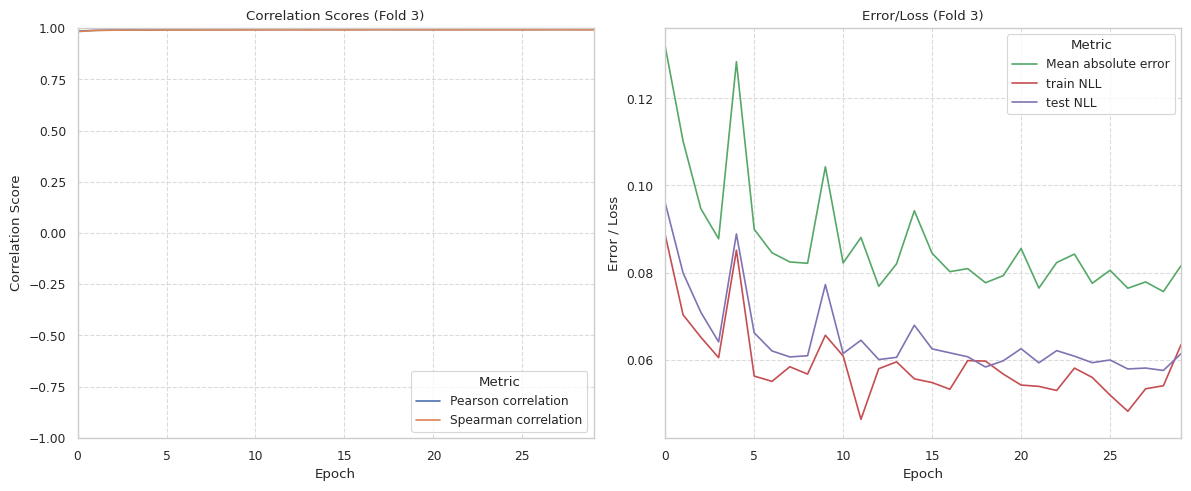

  Saved plot: trained_models/test-2017-30e-5f-smacnp-pw-2/trainingstats_fold4


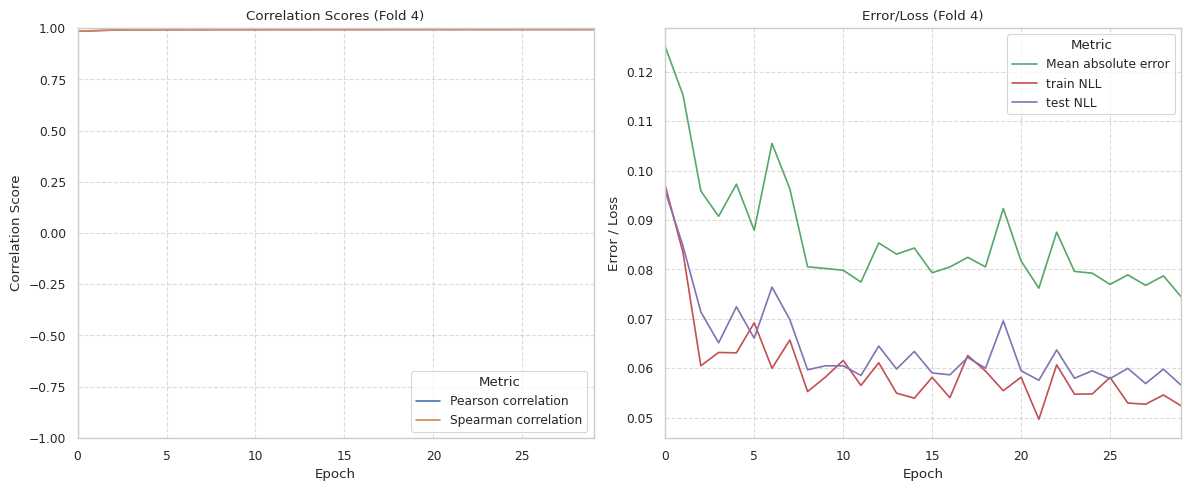

  Saved plot: trained_models/test-2017-30e-5f-smacnp-pw-2/trainingstats_all


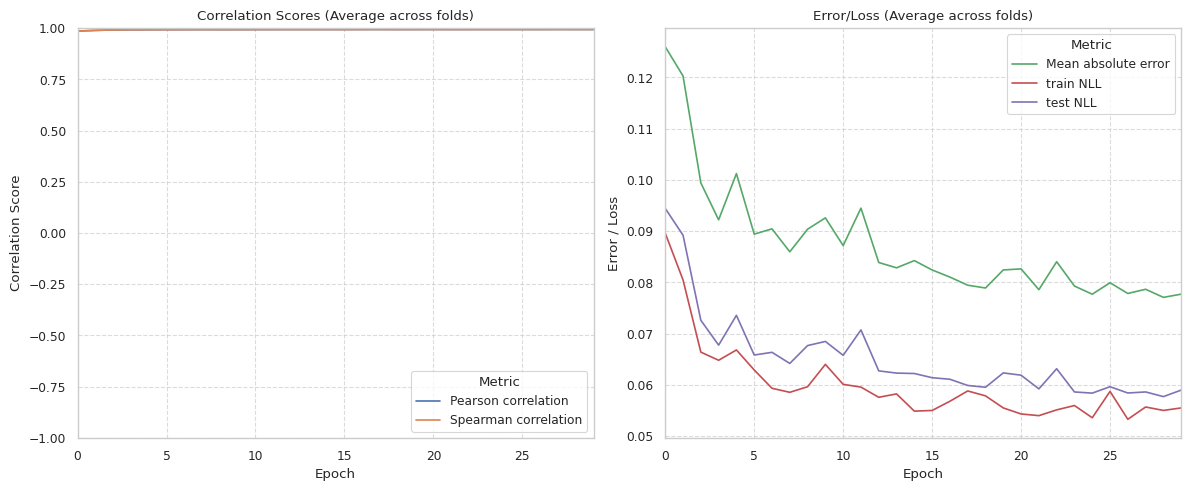

In [ ]:
save_path_prefix = str(OUTPUT_DIR / 'trainingstats')
vis.plot_training_curves(stats, save_path=save_path_prefix)
plt.show()